**Aharouni Refaël, Goder Joshua, Gérard Paul, Montaron Léa, Farhi-Rivasseau Guillaume**
<h1 style="text-align:center; font-weight:bold;"> Hackathon Explainability</h1> <br><br><br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;During this Hackathon of Explainability AI, the 29th team has been called to implement an AI solution (NLP) allowing the company to better understand the employees' quitting rate and their quitting reasons. To do so, the team has been provided with a Kaggle dataset called `HRDataset_v14.csv` containing the personal and professional information of the employees. According to the employees' performance and weights attributed to every performance criteria in the dataset (engagement, number of special projects, absences...), the company will also know if it wants the employee to stay or not regardless of their opinion. Therefore, the LLM (and the application) will serve as a veritable HR management board.<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Over the four themes, two will be chosen: IA & CyberSecurity and Ethical AI. While the IA and Cybersecurity will aim at securing the HR data and prevent AI attacks, the Ethical AI will have for purpose to avoid algorithmic bias and discriminations based on race, origin, gender... This will be achieved through a torough preprocessing and the removal of these features.<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Let us begin this project by importing the needed libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import html
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from tqdm import tqdm
from bs4 import BeautifulSoup, MarkupResemblesLocatorWarning
import warnings
warnings.filterwarnings("ignore", category = MarkupResemblesLocatorWarning)

<br><br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Using the command *read_csv* allows us to import the dataset and to convert it to DataFrame, so that we will be able to work on it. To have a first idea of what it looks like, we will use the *head()* method to display its first lines.

In [2]:
df = pd.read_csv("HRDataset_v14.csv", sep = ",")
df.head(10)

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
5,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,Amy Dunn,11.0,LinkedIn,Exceeds,5.00,5,0,1/7/2019,0,15
6,"Andreola, Colby",10194,0,0,0,1,4,3,0,95660,...,Alex Sweetwater,10.0,LinkedIn,Fully Meets,3.04,3,4,1/2/2019,0,19
7,"Athwal, Sam",10062,0,4,1,1,5,3,0,59365,...,Ketsia Liebig,19.0,Employee Referral,Fully Meets,5.00,4,0,2/25/2019,0,19
8,"Bachiochi, Linda",10114,0,0,0,3,5,3,1,47837,...,Brannon Miller,12.0,Diversity Job Fair,Fully Meets,4.46,3,0,1/25/2019,0,4
9,"Bacong, Alejandro",10250,0,2,1,1,3,3,0,50178,...,Peter Monroe,7.0,Indeed,Fully Meets,5.00,5,6,2/18/2019,0,16


<br><br>

# **1. Analysis and preprocessing of the data**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;We will now proceed to the preprocessing and Feature Engineering of the dataset.

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**A. Variables definition**

* **Employee_Name:** The employee’s full name.
* **EmpID:** The employee's ID in the company.
* **MarriedID:** Boolean indicating if the person is married or not (0 if the employee is not married and 1 if he is married).
* **MaritalStatusID:** Marital status of the employee (single (0), married (1), divorced (2), separated (3), and widowed (4)).
* **GenderID:** Sex of the employee (man (1), woman (0)).
* **EmpStatusID:** ID of the status employment of the employee (from 1 to 5 given if the employee is active or something else).
* **DeptID:**	ID of the department the employee works in (1: administrative offices, 2: executive offices, 3: IT/IS, 4: Software Engineering, 5: Production, 6: Sales).
* **PerfScoreID:** The performance score's ID of the employee (1: "PIP" (Performance Improvement Plan), 2: "Needs Improvement", 3: "Fully Meets", 4: "Exceeds").
* **FromDiversityJobFairID:** Boolean indicating if the employee was referenced in the Diversity Job fair.
* **Salary:** The employee's salary in USD.
*	**Termd:** Boolean indicating if the employee has left the company (0) or not (1).
* **PositionID:** Position ID of the employee in the company (from 1 to 30).
* **Position:** Name of the employee's position inside the company.
* **State:** City the employee lives in.
* **Zip:** Postal code of the city the employee lives in.
*	**DOB:** Birthdate of the employee.
* **Sex:** Sex of the employee ('F' or 'M')
* **MaritalDesc:** The marital status of the person (divorced, single, widowed, separated, etc).     
*	**CitizenDesc:** Boolean indicating if the employee is an eligible citizen (1) or not.
*	**HispanicLatino:** Boolean indicating if the employee is Hispanic/Latino (1) or not (0).
* **RaceDesc:** Race name of the employee.
* **DateofHire:** Date the employee was hired inside the company.
* **DateofTermination:** End date of the employee's contract
* **TermReason:** A description of the reasons pushing the employee to leave.
* **EmploymentStatus:** status employment of the employee (active or something else).
* **Department:** Name of the department the employee works in.
* **ManagerName:** Name of the person’s immediate manager.
* **ManagerID:** ID of the person's immediate manager.
*	**RecruitmentSource:** Source of the employee's employment (Indeed, LinkedIn, Website, Other...).
*	**PerformanceScore:** Performance score of the employee ("PIP", "Needs Improvement", "Fully Meets", and "Exceeds")
* **EngagementSurvey:** Rating of the engagement of the employee inside the company.
*	**EmpSatisfaction:** Rating of the satisfaction of the employee inside the company.
* **SpecialProjectsCount:** The number of special projects that the employee worked on during the last 6 months.
*	**LastPerformanceReview_Date :** The most recent date of the person’s last performance review.
*	**DaysLateLast30 :** The number of times that the employee was late to work during the last 30 days.
* **Absences :** The number of times the employee was absent from work.

<br><br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**B. Missing values**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Before beginning the preprocessing, let us compute the number of columns and rows using the command: *"df.shape"*.

In [3]:
df.shape

(311, 36)

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;From the previous cell, one can remark that we have 311 individuals (311 employees that either have already left the company or are currently working in it). Concerning the features (personal and professional information of the employees), 36 appear in our dataset.

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;We will now check if our dataset contains any missing values using the *info()* method.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;From what one can see here, two features have missing values: *"DateOfTermination"* and *"Manager ID"*. For the *DateofTermination*, it is perhaps caused by the fact that some employees are still in the company ("Termd" = 0). Let us verify this hypothesis by displaying all the employees that have a *"DateofTermination"* but a *"Termd"* at 1.

In [5]:
df[(df["Termd"] == 0) & (df["DateofTermination"].notna())]

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences


<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Because there is not a single individual (employee) that respects these two conditions, we here have the confirmation that the employees who do not have a *"DateofTermination"* are the ones who are still in the company. Therefore, the dataset will be split in two: the training (all the people that already left and have their reasons) and the test (apply the LLM on all the employees still in the company who also have answered the engagement and satisfaction survey).<bR><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;The second feature with missing values is *ManagerID*. However, when we take a look at the values, we see that for some individuals, the cell is missing while other individuals with the same manager do have an ID in this cell. To fix this problem, we will first create a dictionary containing all the correspondances between an ID and a name for the managers to fill the blanks.

In [6]:
mapping = df.dropna(subset = ['ManagerID']).set_index('ManagerName')['ManagerID'].to_dict()
df["ManagerID"] = df["ManagerID"].fillna(df["ManagerName"].map(mapping))

<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Finally, even if it did not seem so, when we looked at the target feature, *TermReason*, we saw that for a lot of tuples, it was not NaN but marked as *N/A-StillEmployed*. To avoid having this, we will just replace it by "".

In [7]:
df["TermReason"] = df["TermReason"].replace("N/A-StillEmployed", "")

<br><br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**C. Useless features**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;As we saw in the introduction, to ensure the absence of bias, some features will need to be deleted. Here is the list of these features and the reason we will delete them using the *drop()* command:<br>
* **MarriedID, MaritalStatusID, GenderID, DOB, Sex, MaritalDesc, CitizenDesc, HispanicLatino**, and **RaceDesc:** These features could constitute a factor of bias/discrimination. <br><br>
* **FromDiversityJobFairID** and **RecruitmentSource:** These features do not give any useful information about the quitting reasons or his opinion on the company.<br><br>
* **PerformanceScore** (qualitative ordinal feature): We already have the *PerfScoreID* feature that has the same role but is easier to manipulate.<br><br>
* **DeptID**, **EmpStatusID**, and **PositionID** (quantitative features): We already have the *Department*, *EmploymentStatus*, and *Position* qualitative features that are more meaningful than the others.<br><br>
* **DateofTermination:** To separate the current employees from the old ones, we only need *Termd*, not the exact date of the end.

In [8]:
df = df.drop(columns = ["MarriedID", "MaritalStatusID", "GenderID", "DOB", "Sex", "MaritalDesc", "CitizenDesc", "HispanicLatino",
                        "RaceDesc", "FromDiversityJobFairID", "PerformanceScore", "DeptID", "EmpStatusID", "PositionID",
                        "DateofTermination", "RecruitmentSource"])

<br><br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**D. Inconsistencies**

#### ***&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$-$ For quantitative features:***

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;We will now deal with the inconsistencies present in the dataset for the quantitative features (the qualitative ones will be treated later). First of all, one can remark from the *info()* command that some features' types are incoherent. For instance, the features *DateofHire* and *LastPerformanceReview_Date* are currently "object" instead of DateTime. Therefore, we will need to convert them to DateTime using the *pd.to_datetime()* command.

In [9]:
df["DateofHire"] = pd.to_datetime(df["DateofHire"], format = "%m/%d/%Y")
df["LastPerformanceReview_Date"] = pd.to_datetime(df["LastPerformanceReview_Date"], format = "%m/%d/%Y")

<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;To simplify things, instead of keeping the feature *LastPerformanceReview_Date*, we will replace it by the number of days since this last review. Afterwards, this initial feature will be deleted.

In [10]:
df["DaysSinceLastReview"] = (pd.Timestamp.today() - df["LastPerformanceReview_Date"]).dt.days
df = df.drop(columns = ["LastPerformanceReview_Date"])

<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;We also remarked that the *ManagerID* feature, which is supposed to be an integer is currently a float64. To convert it, the command *astype(int)* will be used.

In [11]:
df["ManagerID"] = df["ManagerID"].astype(int)

<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;To avoid having any problem with the ZIP code, we will convert this feature to string. All the tuples with less than five numbers will be filled with 0 at the beginning using the *zfill* method.

In [12]:
df['ZIP'] = df['Zip'].astype(str).str.zfill(5)
df = df.drop(columns = ["Zip"])

<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Finally, we will make sure of the coherence of every quantitative feature. For instance, here is what will be checked:
* **EmpID** and **ManagerID:** All the tuples are strictly positive.
* **PerfScoreID:** All the tuples are between one and four.
* **EngagementSurvey** and **EmpSatisfaction:** All the tuples are between one and five.
* **Salary**, **DaysLateLast30**, **Absences**, **DaysSinceLastReview**, and **SpecialProjectCount:** All the tuples are positive (not necessarily strictly)
* **Termd:** All the tuples are either zero, either one
* **DateofHire:** All the tuples are not in the future (before today)

In [13]:
print(f"Inconsistent PerfScoreID? {df[(df['PerfScoreID'] > 4) | (df['PerfScoreID'] < 1)]}\n")
print(f"Inconsistent ManagerID? {df[df["ManagerID"] <= 0]}\n")
print(f"Inconsistent EmpID? {df[df["EmpID"] <= 0]}\n")
print(f"Inconsistent EngagementSurvey? {df[(df['EngagementSurvey'] < 1) | (df['EngagementSurvey'] > 5)]}\n")
print(f"Inconsistent EmpSatisfaction? {df[(df['EmpSatisfaction'] < 1) | (df['EmpSatisfaction'] > 5)]}\n")
print(f"Inconsistent Salary? {df[df['Salary'] < 0]}\n")
print(f"Inconsistent DaysLateLast30? {df[df['DaysLateLast30'] < 0]}\n")
print(f"Inconsistent Absences? {df[df['Absences'] < 0]}\n")
print(f"Inconsistent DaysSinceLastReview? {df[df['DaysSinceLastReview'] < 0]}\n")
print(f"Inconsistent SpecialProjectsCount? {df[df['SpecialProjectsCount'] < 0]}\n")
print(f"Inconsistent Termd? {df[~df['Termd'].isin([0, 1])]}\n")
print(f"Inconsistent DateofHire? {df[df['DateofHire'] > pd.Timestamp.today()]}\n")

Inconsistent PerfScoreID? Empty DataFrame
Columns: [Employee_Name, EmpID, PerfScoreID, Salary, Termd, Position, State, DateofHire, TermReason, EmploymentStatus, Department, ManagerName, ManagerID, EngagementSurvey, EmpSatisfaction, SpecialProjectsCount, DaysLateLast30, Absences, DaysSinceLastReview, ZIP]
Index: []

Inconsistent ManagerID? Empty DataFrame
Columns: [Employee_Name, EmpID, PerfScoreID, Salary, Termd, Position, State, DateofHire, TermReason, EmploymentStatus, Department, ManagerName, ManagerID, EngagementSurvey, EmpSatisfaction, SpecialProjectsCount, DaysLateLast30, Absences, DaysSinceLastReview, ZIP]
Index: []

Inconsistent EmpID? Empty DataFrame
Columns: [Employee_Name, EmpID, PerfScoreID, Salary, Termd, Position, State, DateofHire, TermReason, EmploymentStatus, Department, ManagerName, ManagerID, EngagementSurvey, EmpSatisfaction, SpecialProjectsCount, DaysLateLast30, Absences, DaysSinceLastReview, ZIP]
Index: []

Inconsistent EngagementSurvey? Empty DataFrame
Columns: [

<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Therefore, no inconsistency appears in our dataset for the quantitative features.

<br><br>

#### ***&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$-$ For qualitative features:***

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;We will now preprocess the qualitative features. Because we do not know where the information of this dataset comes from, the qualitative features could contain HTML elements, such as operators or tags, but also emojis, smileys, or images for instance. To deal with this problem, some scanning functions will be defined to look for these elements, while others will be instantiated to remove these elements if they are to be detected (to only keep the text). All the potential parasite spaces will also be deleted in all the qualitative features.

In [14]:
# ----- Detection functions -----
def contains_HTML_tags(text):
    return bool(re.search(r"<[^>]+>", text)) if isinstance(text, str) else False


def contains_HTML_entities(text):
    return bool(re.search(r"&[a-zA-Z]+;", text)) if isinstance(text, str) else False


def contains_emojis(text):
    if not isinstance(text, str):
        return False
    emojis = re.compile("[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF\U00002700-\U000027BF\U000024C2-\U0001F251]+",
                       flags = re.UNICODE)
    return bool(emojis.search(text))


def contains_smileys(text):
    return bool(re.search(r"(:\)|:-\)|:\(|:-\(|;\)|;-\)|:D|:-D|:P|:-P|<3)", text, flags = re.IGNORECASE)) if isinstance(text, str) else False



# ----- Cleaning functions -----
def decoding_html(text: str) -> str:
    return html.unescape(text) if text != "" else ""


def delete_tags_html(text: str) -> str:
    if text != "":
        text = str(text)
        beautifulsoup = BeautifulSoup(text, "html.parser")
        for i in beautifulsoup.find_all('img'):
            i.replace_with(" [IMAGE] ")

        for i in beautifulsoup.find_all('a'):
            i.replace_with(f" [EXTERNAL_LINK: {i.get_text()}] ")

        for i in beautifulsoup(["noscript", "meta", "head", "style", "script"]):
            i.decompose()
        return beautifulsoup.get_text(separator = " ")
    return ""


def normalization(text: str) -> str:
    if text != "":
        text = re.sub(r"[\r\n\t]+", " ", text)
        return re.sub(r"\s+", " ", text).strip()
    return ""


def remove_emojis(text: str) -> str:
    if not isinstance(text, str):
        return ""
    emojis = re.compile("[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF\U00002700-\U000027BF\U000024C2-\U0001F251]+",
                       flags = re.UNICODE)
    return emojis.sub("", text)


def remove_smileys(text: str) -> str:
    if not isinstance(text, str):
        return ""
    return re.sub(r"(:\)|:-\)|:\(|:-\(|;\)|;-\)|:D|:-D|:P|:-P|<3)", "", text, flags = re.IGNORECASE)



def global_cleaning(text):
    if not isinstance(text, str) or text.strip() == "" or text.lower() == "nan":
        return ""
    text = normalization(remove_smileys(remove_emojis(delete_tags_html(decoding_html(text)))))
    if text.strip() == "" or text.lower() == "nan":
        return ""
    return text


def clean_qualitative_features(df):
    for i in df.select_dtypes(include = ['object']).columns:
        series = df[i].dropna()

        has_tags = series.apply(contains_HTML_tags).any()
        has_entities = series.apply(contains_HTML_entities).any()
        has_emojis = series.apply(contains_emojis).any()
        has_smileys = series.apply(contains_smileys).any()

        if (has_tags):
            print(f"{i} has HTML tags.")

        if (has_entities):
            print(f"{i} has HTML entities.")

        if (has_emojis):
            print(f"{i} has emojis.")

        if (has_smileys):
            print(f"{i} has smileys.")

        if any([has_tags, has_entities, has_emojis, has_smileys]):
            df[i] = df[i].apply(global_cleaning)

        else:
          df[i] = df[i].astype(str).str.strip()
    return df


df = clean_qualitative_features(df)
print("\nThe qualitative features have been entirely cleaned.")


The qualitative features have been entirely cleaned.


<br><br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**E. Outliers**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;To go further in our analysis, let us display the boxplot of every quantitative feature to see what the outliers in our dataset are (the points outside the whiskers).

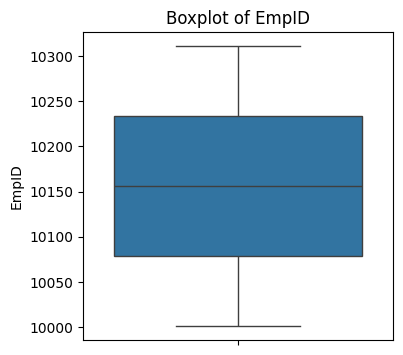

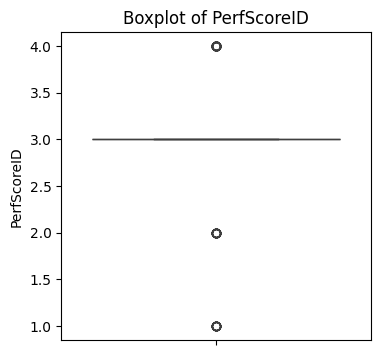

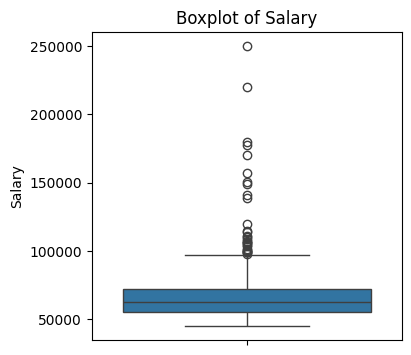

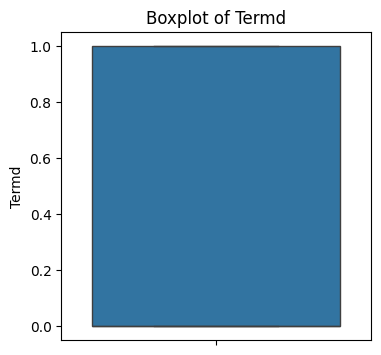

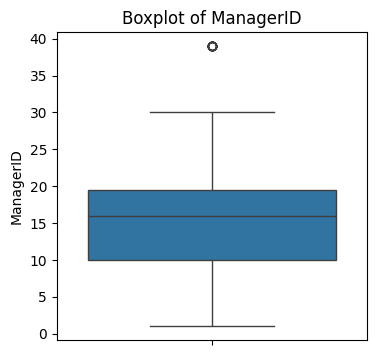

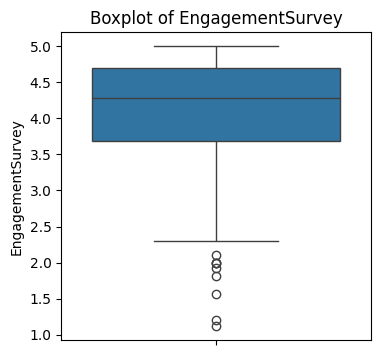

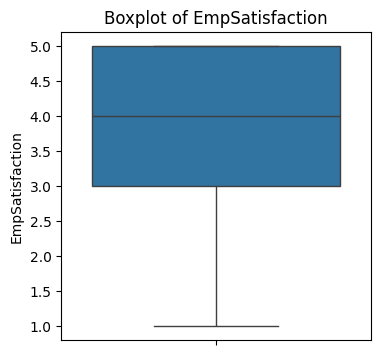

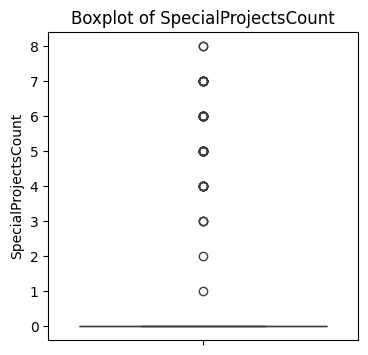

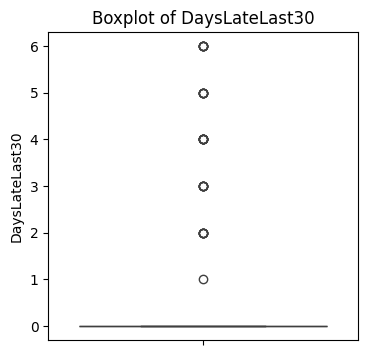

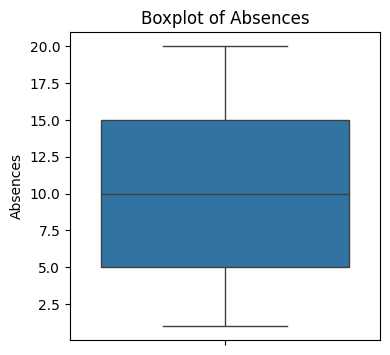

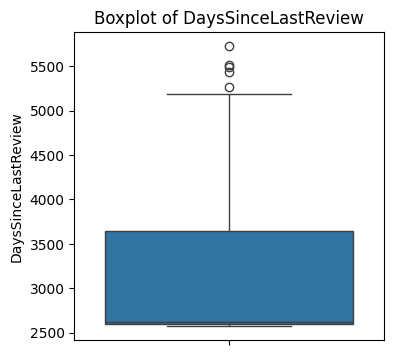

In [15]:
for j in df.select_dtypes(include = ["int64", "float64"]).columns: # We select the quantitative features
  plt.figure(figsize = (4, 4)) # Creation of a new figure
  sns.boxplot(df[j]) # Display of boxplot
  plt.title(f"Boxplot of {j}")
  plt.show()

<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;From what one can see in these boxplots, some quantitative features have extreme values. For instance, here, the salary data are skewed by a few executive roles earning up to \$250,000, while the median sits much lower at \$63,000. These outliers might pull the average and cause an overgeneralization of the algorithm based on a few high-income individuals. To address this issue without losing valuable information, we opted for a logarithmic smoothing of the salary feature.<br>
Nonetheless, we will not do anything to remove the outliers for the quantitative discrete features because of what they represent here (IDs, number of absences, number of days...). It would also cause some perturbation on the performance metrics, as we will say later.

In [16]:
df['LogSalary'] = np.log(df['Salary'])

<br><br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**F. Creation of a new feature: isSatisfiedCompany**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;

<br><br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**G. Duplicates**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Let us conclude the preprocessing and Feature Engineering by removing the potential duplicates. The first thing to do is to verify if some duplicates exist using the *df.duplicated().sum()* method.

In [17]:
print(f"There are {df.duplicated().sum()} duplicates in our dataset that are:")
df[df.duplicated()]

There are 0 duplicates in our dataset that are:


,Employee_Name,EmpID,PerfScoreID,Salary,Termd,Position,State,DateofHire,TermReason,EmploymentStatus,...,ManagerName,ManagerID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,DaysSinceLastReview,ZIP,LogSalary


In [18]:
df.to_csv("df.csv", index = False)

<br><br>

# **2. Implementation of the NLP**

In [19]:
df.groupby("Department")["Termd"].mean()

,Termd
Department,
Admin Offices,0.222222
Executive Office,0.000000
IT/IS,0.200000
Production,0.397129
Sales,0.161290
Software Engineering,0.363636
